In [1]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import graphviz as gv
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install bambi

In [3]:
import bambi as bmb

#Introduction and Data

I decided to do my project based on the octopus data set in Mr. Arredondo's GitHub. The data set has values of total octopus weight, upper beak length, lower beak length, and lateral wall length. My goal is to determine what model is best to predict total octopus weight.

In [16]:
octopusog = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/octopusbeakweight_nlin.csv')

In [17]:
octopusog

,totWt,upBeak,loBeak,latWall
0,91,78,78,74
1,532,125,120,131
2,537,101,92,138
3,605,85,107,135
4,647,130,101,155
5,708,139,167,165
6,724,114,143,147
7,900,105,108,127
8,925,129,160,221
9,1074,159,177,168


There is a data value that is an outlier and messes up my models, I am eliminating it from the data set below.

In [18]:
octopus = octopusog[octopusog['latWall'] >= 100]

In [19]:
octopus

,totWt,upBeak,loBeak,latWall
1,532,125,120,131
2,537,101,92,138
3,605,85,107,135
4,647,130,101,155
5,708,139,167,165
6,724,114,143,147
7,900,105,108,127
8,925,129,160,221
9,1074,159,177,168
10,1106,107,117,138


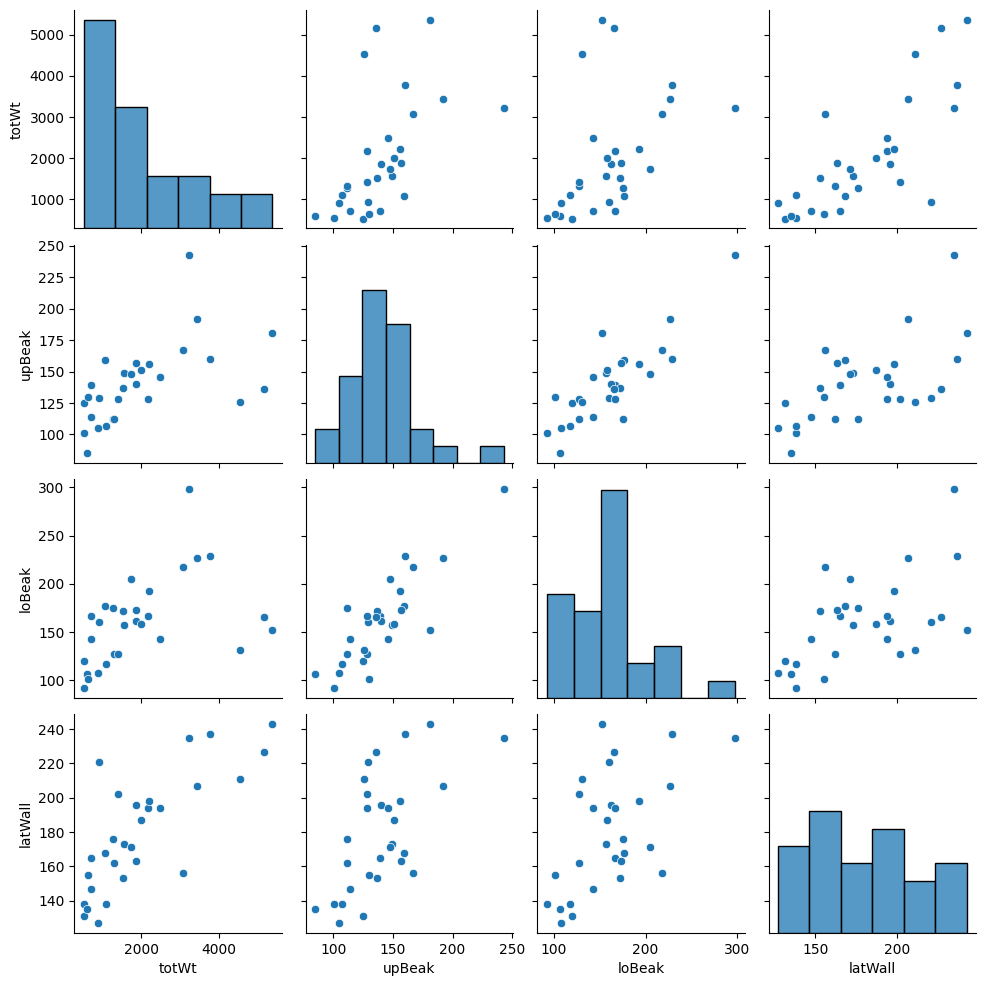

In [20]:
sns.pairplot(octopus)

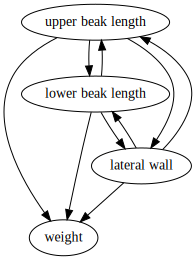

In [21]:
b_dag = gv.Digraph(name="Octopus DAG")

b_dag.node('W','weight')
b_dag.node('U','upper beak length')
b_dag.node('L','lower beak length')
b_dag.node('A','lateral wall')

b_dag.edges(['UA','AU','LA','AL','UL','LU','LW', 'AW','UW'])

b_dag


For my models, I am going to run single variable (Lateral Wall) models as well as models encompassing all three variables. It is my belief that Lateral Wall will be the best predictor as it encompasses the most of the beak.

# Linear Lateral Wall Model

I will start with a linear model.

In [ ]:
model1 = bmb.Model("totWt ~ latWall", octopus)
idata1 = model1.fit(idata_kwargs={'log_likelihood': True})

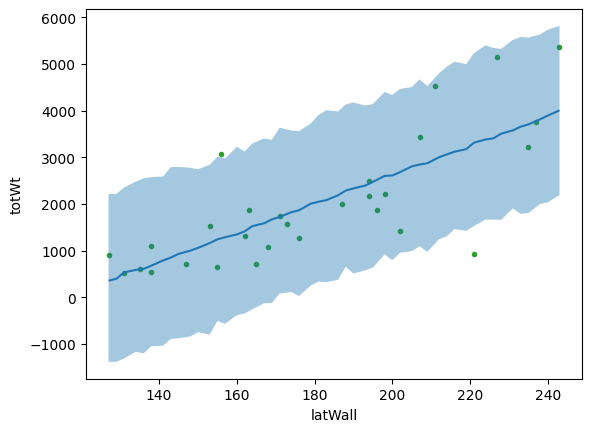

In [23]:
bmb.interpret.plot_predictions(model1, idata1, "latWall", pps=True)
plt.plot(octopus.latWall, octopus.totWt, "C2.", zorder=-3)

Overall, this model does a pretty good job of encompassing the data trends, but it could be refined. I am going to try using a polynomial model now.

# Polynomial Lateral Wall Model

In [ ]:
model2 = bmb.Model("totWt ~ poly(latWall, degree = 4)", octopus)
idata2 = model2.fit(idata_kwargs={'log_likelihood': True})

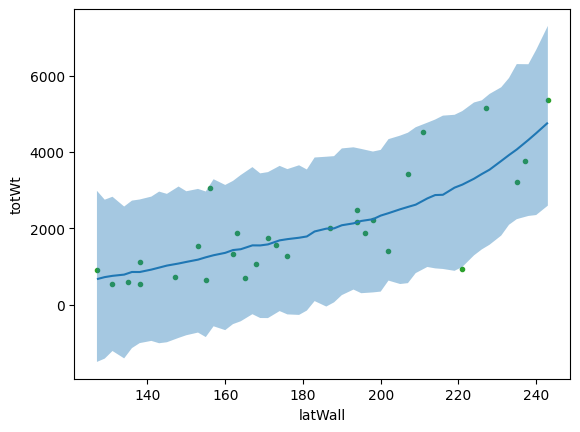

In [25]:
bmb.interpret.plot_predictions(model2, idata2, "latWall", pps=True)
plt.plot(octopus.latWall, octopus.totWt, "C2.", zorder=-3)

This is pretty good, but still missing some data points. Maybe this could be refined with a b spline?

# B Spline Lateral Wall Model

In [26]:
# Get the row with the lowest score
lowest_row = octopus.nsmallest(n=1, columns=['latWall'])
print("Row with lowest score:\n", lowest_row)

# Get the row with the highest score
highest_row = octopus.nlargest(n=1, columns=['latWall'])
print("\nRow with highest score:\n", highest_row)

Row with lowest score:
    totWt  upBeak  loBeak  latWall
7    900     105     108      127

Row with highest score:
     totWt  upBeak  loBeak  latWall
29   5361     181     152      243


In [ ]:
num_knots = 6
min_latWall = 127
max_latWall = 243
knots = np.linspace(min_latWall, max_latWall, num_knots+2)[1:-1]
model3 = bmb.Model("totWt ~ bs(latWall, degree=3, knots=knots)", octopus)
idata3 = model3.fit(idata_kwargs={'log_likelihood':True})

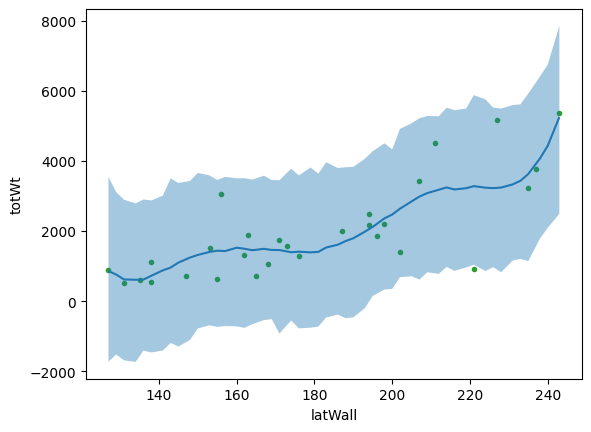

In [30]:
bmb.interpret.plot_predictions(model3, idata3, "latWall", pps=True)
plt.plot(octopus.latWall, octopus.totWt, "C2.", zorder=-3)

# Multiple Linear Model

In [ ]:
model4 = bmb.Model("totWt ~ latWall + upBeak + loBeak", data=octopus)
idata4 = model4.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x1300 with 1 Axes>,
 array([<Axes: xlabel='upBeak', ylabel='totWt'>], dtype=object))

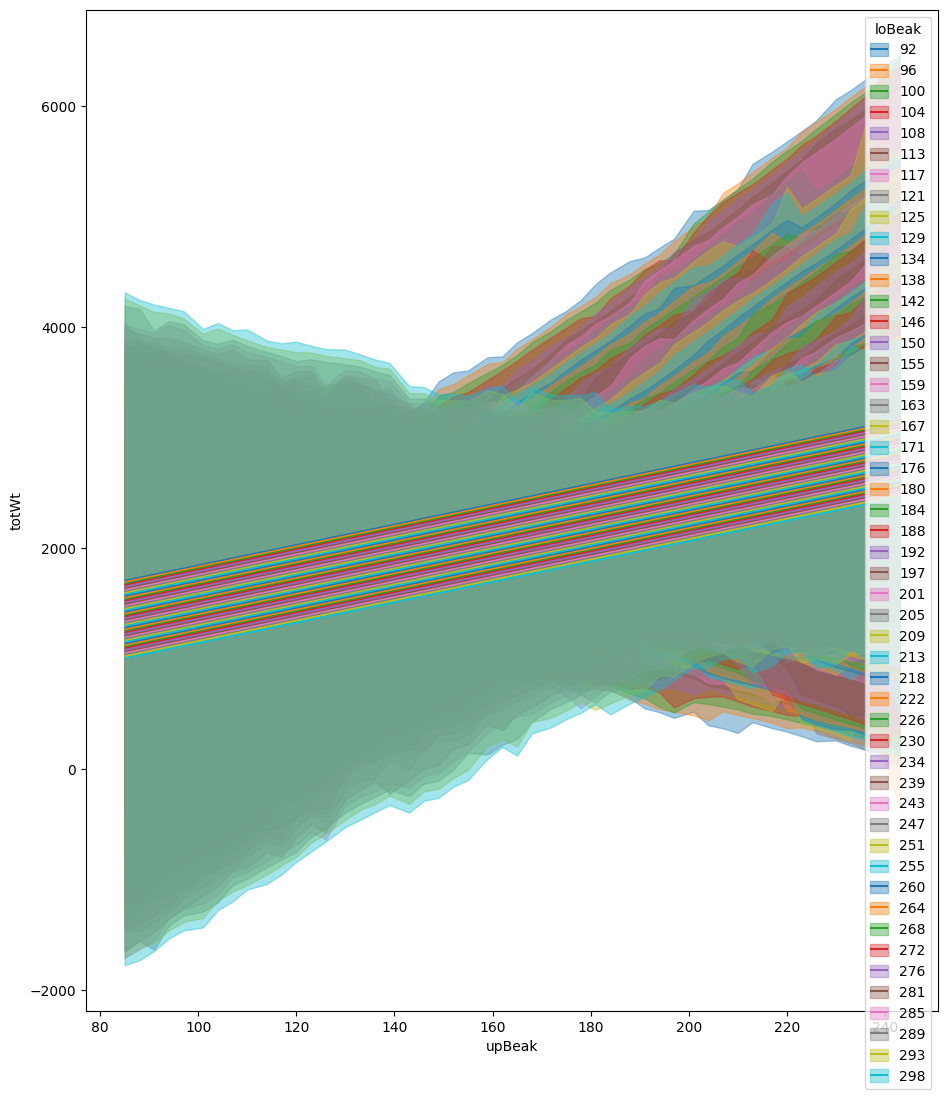

In [33]:
bmb.interpret.plot_predictions(model4,
                               idata4,
                               ["upBeak","loBeak"],
                               fig_kwargs={"figsize":(11, 13)})

# Multiple B Spline Model

In [34]:
# Get the row with the lowest score
lowest_row = octopus.nsmallest(n=1, columns=['upBeak'])
print("Row with lowest score:\n", lowest_row)

# Get the row with the highest score
highest_row = octopus.nlargest(n=1, columns=['upBeak'])
print("\nRow with highest score:\n", highest_row)

Row with lowest score:
    totWt  upBeak  loBeak  latWall
3    605      85     107      135

Row with highest score:
     totWt  upBeak  loBeak  latWall
24   3217     243     298      235


In [35]:
# Get the row with the lowest score
lowest_row = octopus.nsmallest(n=1, columns=['loBeak'])
print("Row with lowest score:\n", lowest_row)

# Get the row with the highest score
highest_row = octopus.nlargest(n=1, columns=['loBeak'])
print("\nRow with highest score:\n", highest_row)

Row with lowest score:
    totWt  upBeak  loBeak  latWall
2    537     101      92      138

Row with highest score:
     totWt  upBeak  loBeak  latWall
24   3217     243     298      235


In [ ]:
knots_latWall = [140, 170, 200, 225]
knots_upBeak = [100, 125, 150, 220]
knots_loBeak = [120, 140, 190, 270]
model5 = bmb.Model("totWt ~ bs(latWall, degree = 3, knots = knots_latWall) + bs(upBeak, degree = 3, knots = knots_upBeak) + bs(loBeak, degree = 3, knots = knots_loBeak)", data = octopus)
idata5 = model5.fit(idata_kwargs={'log_likelihood': True})

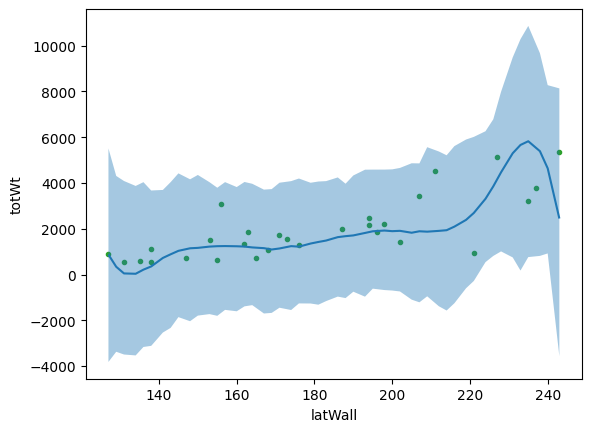

In [52]:
bmb.interpret.plot_predictions(model5, idata5, "latWall", pps=True)
plt.plot(octopus.latWall, octopus.totWt, "C2.", zorder=-3)

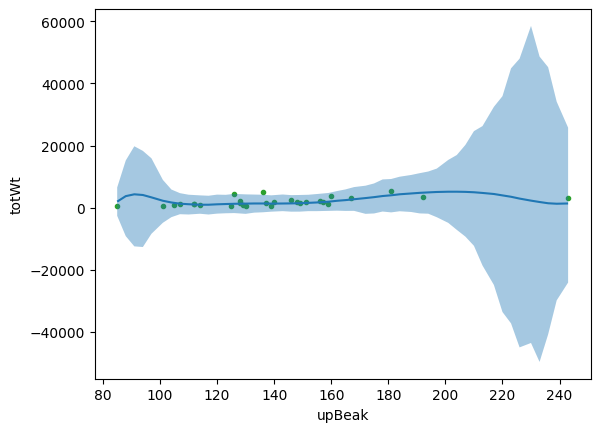

In [53]:
bmb.interpret.plot_predictions(model5, idata5, "upBeak", pps=True)
plt.plot(octopus.upBeak, octopus.totWt, "C2.", zorder=-3)

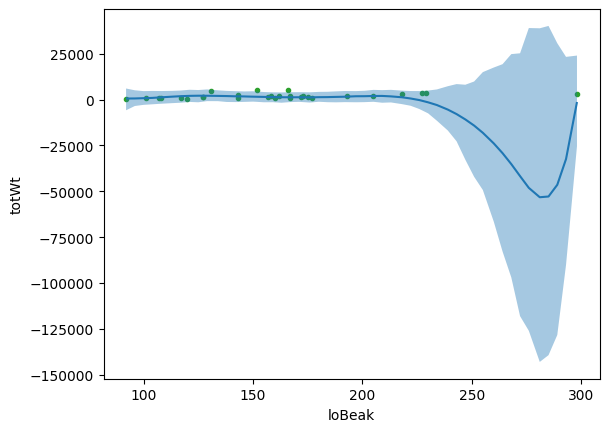

In [54]:
bmb.interpret.plot_predictions(model5, idata5, "loBeak", pps=True)
plt.plot(octopus.loBeak, octopus.totWt, "C2.", zorder=-3)

# Comparison

In [ ]:
cmp = az.compare({"1": idata1,"2": idata2, "3": idata3, "4": idata4, "5": idata5})

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

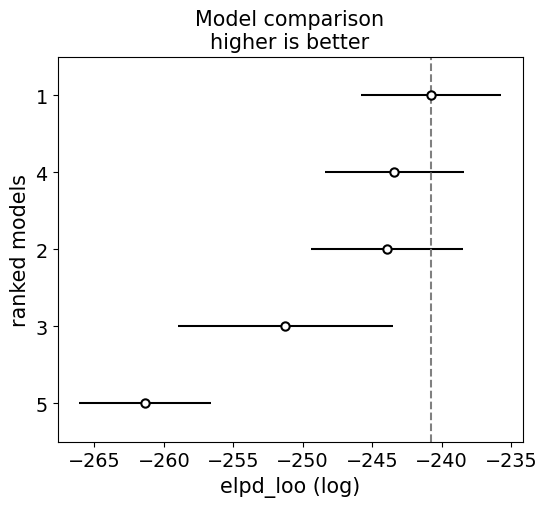

In [56]:
az.plot_compare(cmp)

This shows that the linear model using just lateral wall performed the best, followed by the linear model with multiple predictors. Overall, linear modeling is the best way to go for this dataset to predict total weight of octopi.